# Mini Exploratory Data Analysis (EDA) on Titanic Dataset

## Objective
The objective of this project is to perform Exploratory Data Analysis (EDA) on the Titanic dataset to identify factors affecting passenger survival.

## Goals
- Clean the dataset by handling missing values.
- Analyze survival rates based on Age Group.
- Analyze survival rates based on Embarkation Port.
- Analyze survival rates based on Family Size.
- Create meaningful visualizations.
- Derive insights from the data.

## Tools Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Google Colab

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [4]:
import pandas as pd

df = pd.read_csv('Titanic-Dataset.csv')

## Dataset Overview

Understanding the structure of the dataset before cleaning.

# Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is the process of examining, summarizing, and visualizing data to understand its structure, identify patterns, detect anomalies, and generate insights.

In this project, we will:
- Explore the Titanic dataset.
- Clean and preprocess the data.
- Handle missing values.
- Create new meaningful features.
- Analyze survival trends.
- Visualize relationships among variables.
- Draw conclusions based on observations.

In [11]:
print("Rows and Columns:", df.shape)

df.info()

df.describe()

Rows and Columns: (891, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 76.7+ KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.002015,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,29.699118,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## Missing Values Analysis

Identifying columns with missing values.

## Initial Data Exploration

Before performing any analysis, it is important to understand:

- Number of rows and columns.
- Data types of variables.
- Presence of missing values.
- Distribution of numerical features.
- Potential issues affecting analysis.

This step helps determine the preprocessing strategy.

In [12]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


## Data Cleaning and Preprocessing

Real-world datasets often contain incomplete or inconsistent data.

The Titanic dataset contains missing values in columns such as Age and Cabin.

Cleaning is necessary because:
- Machine learning and statistical methods require complete data.
- Missing values can bias results.
- Proper preprocessing improves analysis quality.

The following cleaning steps will be performed:
1. Impute missing Age values using the mean.
2. Fill missing Embarked values using the mode.
3. Remove Cabin because it contains too many missing values.

In [14]:
# Fill Age with mean
df['Age'] = df['Age'].fillna(df['Age'].mean())

# Fill Embarked with mode
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Drop Cabin
if 'Cabin' in df.columns:
    df.drop('Cabin', axis=1, inplace=True)

df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


## Feature Engineering

Feature engineering involves creating new variables from existing data to improve analysis.

Two new features are created:

### Age Group
Passengers are categorized into age ranges for easier interpretation.

### Family Size
Family Size = SibSp + Parch

This feature helps us study whether travelling with family influenced survival chances.

In [15]:
# Age Groups

df['Age_Group'] = pd.cut(
    df['Age'],
    bins=[0,12,19,59,100],
    labels=['Child','Teen','Adult','Senior']
)

# Family Size

df['Family_Size'] = df['SibSp'] + df['Parch']

df[['Age_Group','Family_Size']].head()

,Age_Group,Family_Size
0,Adult,1
1,Adult,1
2,Adult,0
3,Adult,1
4,Adult,0


# Survival Analysis

The primary objective of this analysis is to understand which factors affected passenger survival.

We will investigate:

1. Survival Rate by Age Group
2. Survival Rate by Embarkation Port
3. Survival Rate by Family Size

GroupBy operations will be used to calculate average survival rates across different categories.

## Analysis 1: Survival Rate by Age Group

In [16]:
age_survival = df.groupby('Age_Group')['Survived'].mean()*100

age_survival

/tmp/ipykernel_945/1061306482.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_survival = df.groupby('Age_Group')['Survived'].mean()*100


,Survived
Age_Group,
Child,57.971014
Teen,41.052632
Adult,36.519258
Senior,26.923077


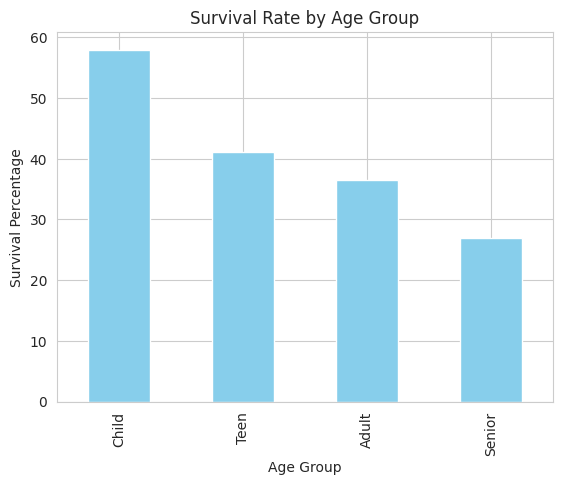

In [17]:
age_survival.plot(
    kind='bar',
    color='skyblue'
)

plt.title('Survival Rate by Age Group')
plt.ylabel('Survival Percentage')
plt.xlabel('Age Group')
plt.show()

### Insight
- Compare survival rates among children, teens, adults and seniors.
- Higher survival among children supports the "Women and Children First" evacuation strategy.

## Analysis 2: Survival Rate by Embarkation Port

In [18]:
embark_survival = df.groupby('Embarked')['Survived'].mean()*100

embark_survival

,Survived
Embarked,
C,55.357143
Q,38.961039
S,33.900929


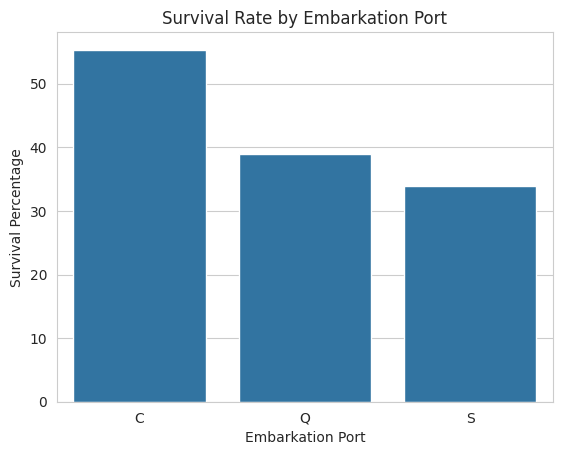

In [19]:
sns.barplot(
    x=embark_survival.index,
    y=embark_survival.values
)

plt.title('Survival Rate by Embarkation Port')
plt.xlabel('Embarkation Port')
plt.ylabel('Survival Percentage')
plt.show()

### Insight
Different embarkation ports show varying survival rates, indicating possible socio-economic or class-related differences.

## Analysis 3: Survival Rate by Family Size

In [20]:
family_survival = df.groupby('Family_Size')['Survived'].mean()*100

family_survival

,Survived
Family_Size,
0,30.353818
1,55.279503
2,57.843137
3,72.413793
4,20.000000
5,13.636364
6,33.333333
7,0.000000
10,0.000000


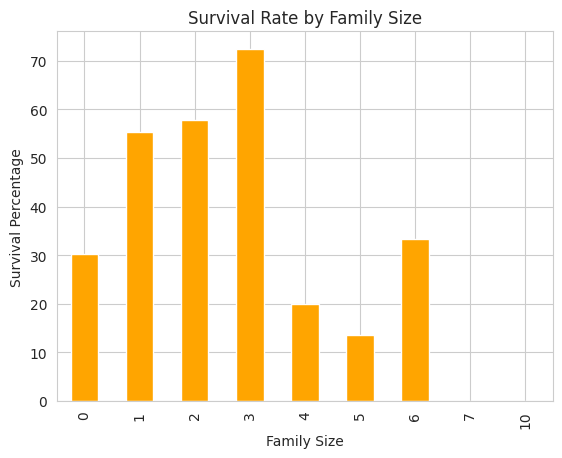

In [21]:
family_survival.plot(
    kind='bar',
    color='orange'
)

plt.title('Survival Rate by Family Size')
plt.xlabel('Family Size')
plt.ylabel('Survival Percentage')
plt.show()

### Insight
Passengers travelling with small families often had better survival rates compared to those travelling alone or in very large families.

## Survival by Age Group

Age may have played an important role during the evacuation process.

This analysis examines whether children, teenagers, adults, and seniors experienced different survival outcomes.

## Visualization 1: Age Distribution

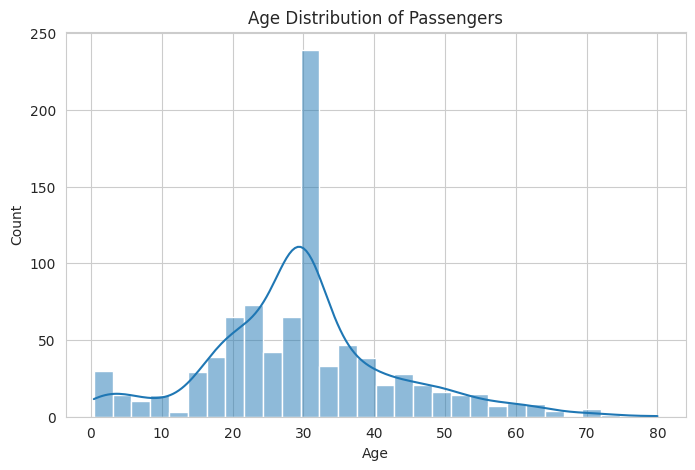

In [22]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Age'],
    bins=30,
    kde=True
)

plt.title('Age Distribution of Passengers')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

### Insight
Most passengers were young adults, with fewer elderly passengers onboard.

## Visualization 2: Correlation Heatmap

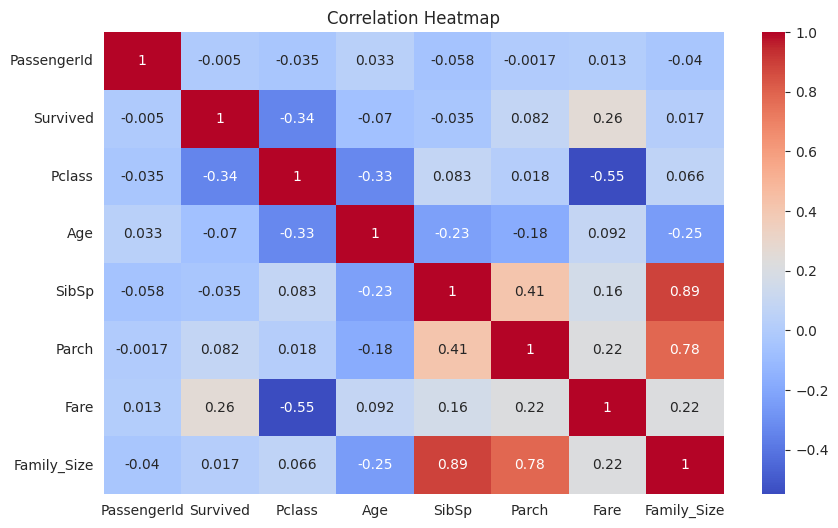

In [23]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')
plt.show()

### Insight
- Positive values indicate direct relationships.
- Negative values indicate inverse relationships.
- Observe how Passenger Class, Fare, and Survival interact.

## Survival by Passenger Class

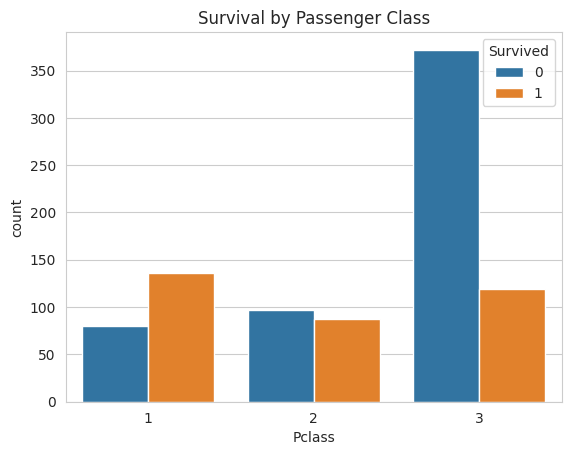

In [24]:
sns.countplot(
    x='Pclass',
    hue='Survived',
    data=df
)

plt.title('Survival by Passenger Class')
plt.show()

### Insight
First-class passengers had a noticeably higher survival rate than third-class passengers.

## Survival by Gender

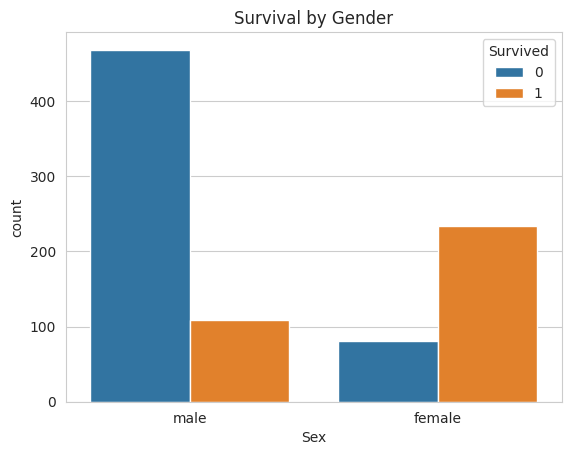

In [25]:
sns.countplot(
    x='Sex',
    hue='Survived',
    data=df
)

plt.title('Survival by Gender')
plt.show()

### Insight
Female passengers experienced significantly higher survival rates than male passengers.

# Summary of Insights

After cleaning, transforming, and visualizing the data, we can summarize the most important findings obtained from the analysis.

# Key Findings

1. Children had comparatively higher survival rates.
2. Survival differed across embarkation ports.
3. Small family groups showed better survival chances.
4. Female passengers survived more frequently.
5. First-class passengers had a survival advantage.
6. Passenger age distribution was concentrated among adults.
7. Fare and passenger class showed relationships with survival.

These findings suggest that age, gender, passenger class, family structure, and embarkation location all influenced survival outcomes.

# Conclusion

This Mini EDA explored survival patterns within the Titanic dataset using data cleaning, feature engineering, groupby analysis, and visualization techniques.

The analysis revealed that survival was influenced by demographic and socio-economic factors such as age, gender, passenger class, family size, and embarkation port.

This project demonstrates essential data science skills including:
- Data Cleaning
- Missing Value Handling
- Feature Engineering
- Exploratory Data Analysis (EDA)
- Data Visualization
- Insight Generation